### What You Need to Do
1. Load and Preprocess the MNIST Dataset
    - Load the MNIST dataset using TensorFlow/Keras
    - Normalize the image pixel values to be between 0 and 1
    - Convert labels into one-hot encoded format
    - Split the dataset into training and test sets
    - Display sample images with their corresponding labels
2. Build a Fully Connected Neural Network
    - Define a sequential model using Keras
    - Flatten the 28x28 input images into a single vector
    - Add two hidden layers with ReLU activation
    - Add an output layer with Softmax activation for multi-class classification
    - Compile the model using categorical cross-entropy as the loss function and accuracy as the evaluation metric
3. Train the Neural Network
    - Fit the model to the training data for 10 epochs
    - Use a validation set to track performance during training
    - Observe the loss and accuracy trends over the epochs
4. Evaluate the Model’s Performance
    - Compute accuracy on the test dataset
    - Display a confusion matrix for misclassified digits
    - Identify which digits the model struggles with the most


### Solution

In [20]:
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Normalize pixel values
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# One-hot encode labels
y_train_oh = keras.utils.to_categorical(y_train, num_classes=10)
y_test_oh = keras.utils.to_categorical(y_test, num_classes=10)

print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)
print("y_train one-hot shape:", y_train_oh.shape)
print("y_test one-hot shape:", y_test_oh.shape)

x_train shape: (60000, 28, 28)
x_test shape: (10000, 28, 28)
y_train one-hot shape: (60000, 10)
y_test one-hot shape: (10000, 10)


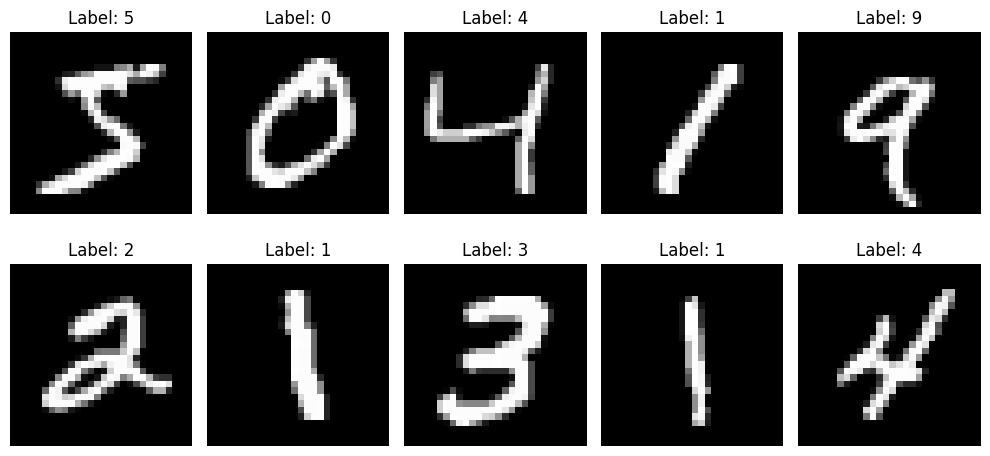

In [ ]:
# Display sample images with labels
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Build the fully connected neural network
model = keras.Sequential([
    keras.Input(shape=(28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the network
history = model.fit(
    x_train,
    y_train_oh,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 759us/step - accuracy: 0.9267 - loss: 0.2487 - val_accuracy: 0.9645 - val_loss: 0.1175
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 720us/step - accuracy: 0.9674 - loss: 0.1068 - val_accuracy: 0.9702 - val_loss: 0.1040
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 677us/step - accuracy: 0.9767 - loss: 0.0749 - val_accuracy: 0.9753 - val_loss: 0.0848
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 630us/step - accuracy: 0.9819 - loss: 0.0560 - val_accuracy: 0.9747 - val_loss: 0.0869
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 593us/step - accuracy: 0.9858 - loss: 0.0443 - val_accuracy: 0.9782 - val_loss: 0.0828
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 646us/step - accuracy: 0.9890 - loss: 0.0347 - val_accuracy: 0.9760 - val_loss: 0.0901
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 728us/step - accuracy: 0.9901 - loss: 0.0293 - val_accuracy: 0.9748 - val_loss: 0.0942
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 692us/step - accuracy: 0.9914 -

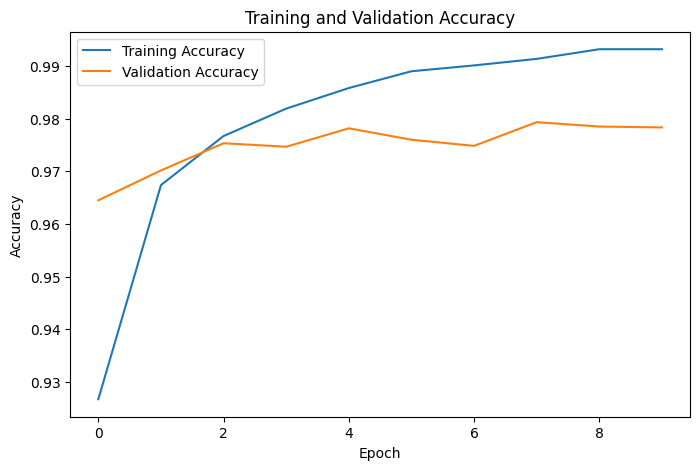

In [24]:
# Accuracy plot
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

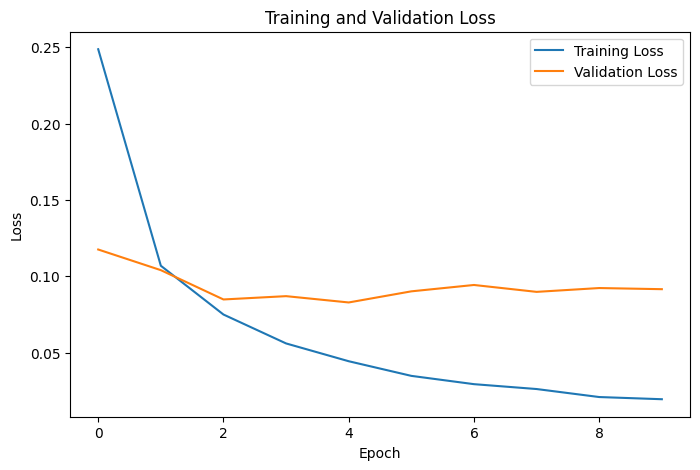

In [25]:
# Loss plot
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [ ]:
# Evaluate on the test set
test_loss, test_accuracy = model.evaluate(x_test, y_test_oh)
print(f"Test accuracy: {test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 325us/step - accuracy: 0.9796 - loss: 0.0841
Test accuracy: 0.9796


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 275us/step


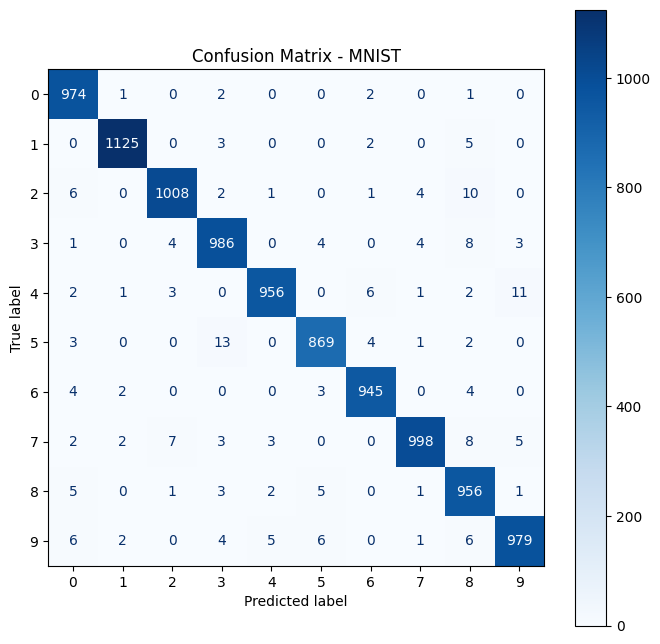

In [27]:
# Predict probabilities
y_pred_probs = model.predict(x_test)

# Convert probabilities to predicted class labels
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(10))
fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap='Blues', ax=ax)
plt.title("Confusion Matrix - MNIST")
plt.show()

In [ ]:
# Identify which digits the model struggles with most
# Number of mistakes per true class
mistakes_per_digit = cm.sum(axis=1) - np.diag(cm)

for digit, mistakes in enumerate(mistakes_per_digit):
    print(f"Digit {digit}: {mistakes} mistakes")

hardest_digit = np.argmax(mistakes_per_digit)
print(f"\nThe digit the model struggles with most is: {hardest_digit}")

Digit 0: 6 mistakes
Digit 1: 10 mistakes
Digit 2: 24 mistakes
Digit 3: 24 mistakes
Digit 4: 26 mistakes
Digit 5: 23 mistakes
Digit 6: 13 mistakes
Digit 7: 30 mistakes
Digit 8: 18 mistakes
Digit 9: 30 mistakes

The digit the model struggles with most is: 7


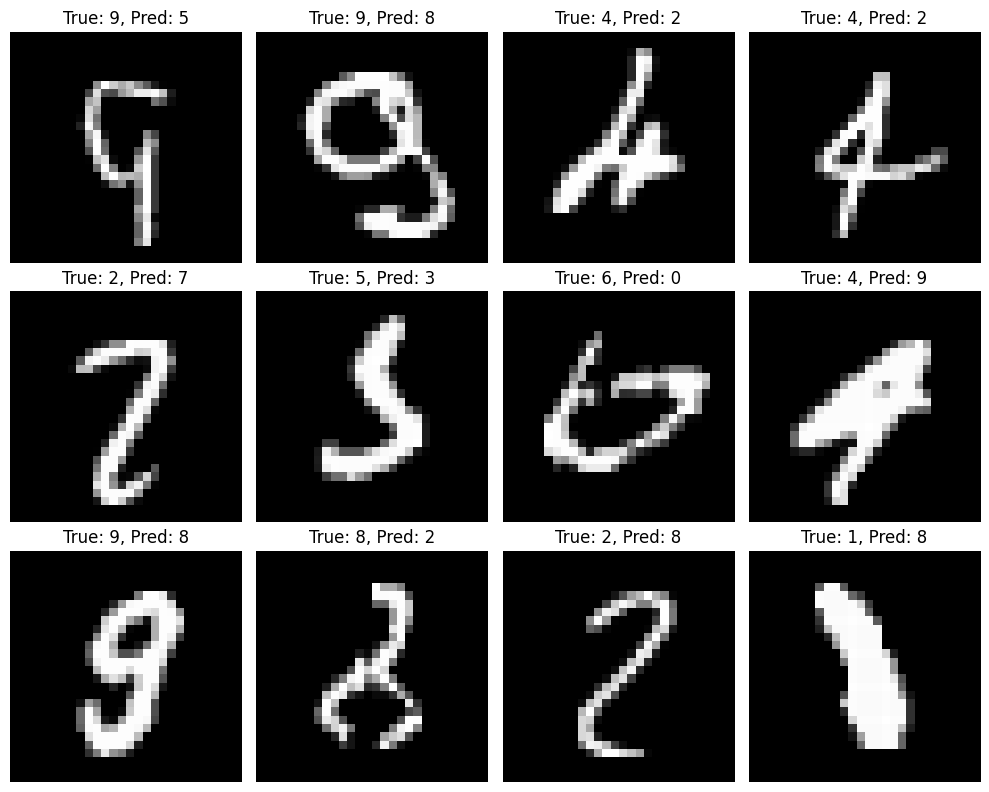

In [ ]:
# show some misclassified images
misclassified = np.where(y_pred != y_test)[0]

plt.figure(figsize=(10, 8))
for i, idx in enumerate(misclassified[:12]):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[idx], cmap='gray')
    plt.title(f"True: {y_test[idx]}, Pred: {y_pred[idx]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

*Observation*: The fully connected neural network performed well on the MNIST dataset, reaching high accuracy on the test set. The training and validation curves showed that the model learned effectively over the epochs. The confusion matrix revealed that some digits were occasionally confused with visually similar digits, such as 4 and 9 or 3 and 5. Overall, the model achieved strong multi-class classification performance on handwritten digit recognition.